In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
project_root = Path.cwd().parent

data_path = (
    project_root
    / "ml"
    / "data"
    / "raw"
    / "Metro_Interstate_Traffic_Volume.csv"
)

df = pd.read_csv(data_path)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
df.shape

(48204, 9)

In [ ]:
df.info()

<bound method DataFrame.info of       holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
0         NaN  288.28      0.0      0.0          40        Clouds   
1         NaN  289.36      0.0      0.0          75        Clouds   
2         NaN  289.58      0.0      0.0          90        Clouds   
3         NaN  290.13      0.0      0.0          90        Clouds   
4         NaN  291.14      0.0      0.0          75        Clouds   
...       ...     ...      ...      ...         ...           ...   
48199     NaN  283.45      0.0      0.0          75        Clouds   
48200     NaN  282.76      0.0      0.0          90        Clouds   
48201     NaN  282.73      0.0      0.0          90  Thunderstorm   
48202     NaN  282.09      0.0      0.0          90        Clouds   
48203     NaN  282.12      0.0      0.0          90        Clouds   

          weather_description            date_time  traffic_volume  
0            scattered clouds  2012-10-02 09:00:00            5545  
1

In [5]:
df.describe(
    
)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [6]:
# Checking Missing Values
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

holiday                99.873454
temp                    0.000000
rain_1h                 0.000000
snow_1h                 0.000000
clouds_all              0.000000
weather_main            0.000000
weather_description     0.000000
date_time               0.000000
traffic_volume          0.000000
dtype: float64

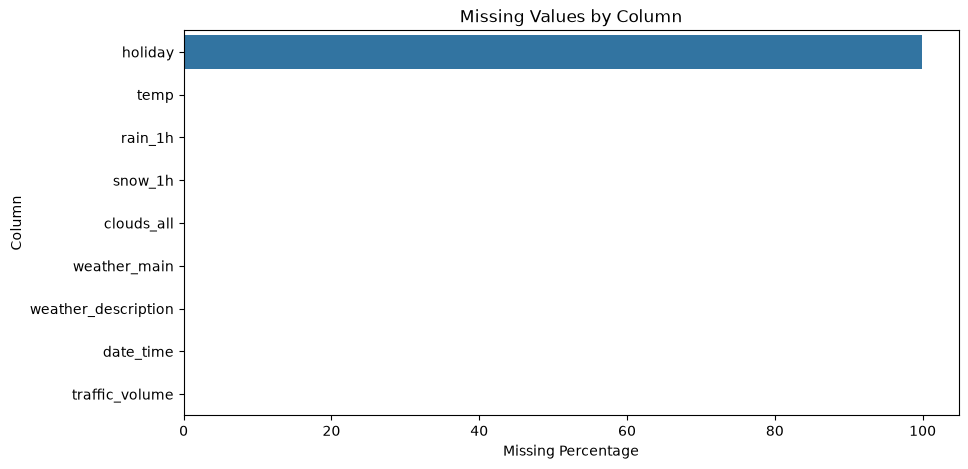

In [10]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")

plt.show()

In [11]:
df.duplicated().sum()

np.int64(17)

In [15]:
# check datatype 
df["date_time"].dtype

<StringDtype(storage='python', na_value=nan)>

In [17]:
# convert it into datetime
df["date_time"] = pd.to_datetime(df["date_time"]) 
df["date_time"].dtype

dtype('<M8[us]')

In [19]:
# 8. Create Temporary Time Features
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["day_name"] = df["date_time"].dt.day_name()
df["month_name"] = df["date_time"].dt.month_name()

In [20]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,month,day,hour,day_of_week,day_name,month_name
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012,10,2,9,1,Tuesday,October
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012,10,2,10,1,Tuesday,October
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012,10,2,11,1,Tuesday,October
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012,10,2,12,1,Tuesday,October
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012,10,2,13,1,Tuesday,October


In [21]:
df["traffic_volume"].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

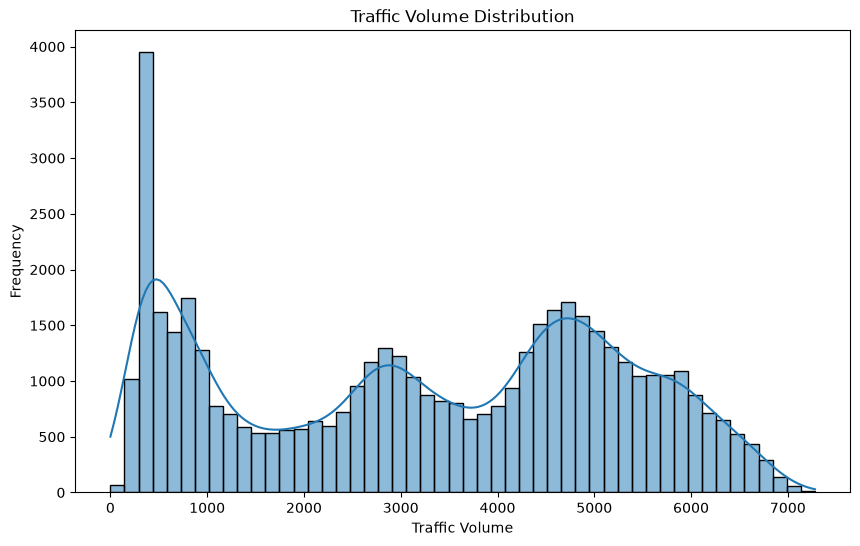

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="traffic_volume",
    bins=50,
    kde=True
)

plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

In [23]:
hourly_traffic = (
    df.groupby("hour")["traffic_volume"]
    .mean()
    .reset_index()
)

hourly_traffic

,hour,traffic_volume
0,0,834.781051
1,1,516.449000
2,2,388.353640
3,3,371.090864
4,4,702.551889
5,5,2094.573437
6,6,4140.503594
7,7,4740.181337
8,8,4587.497115
9,9,4385.277502


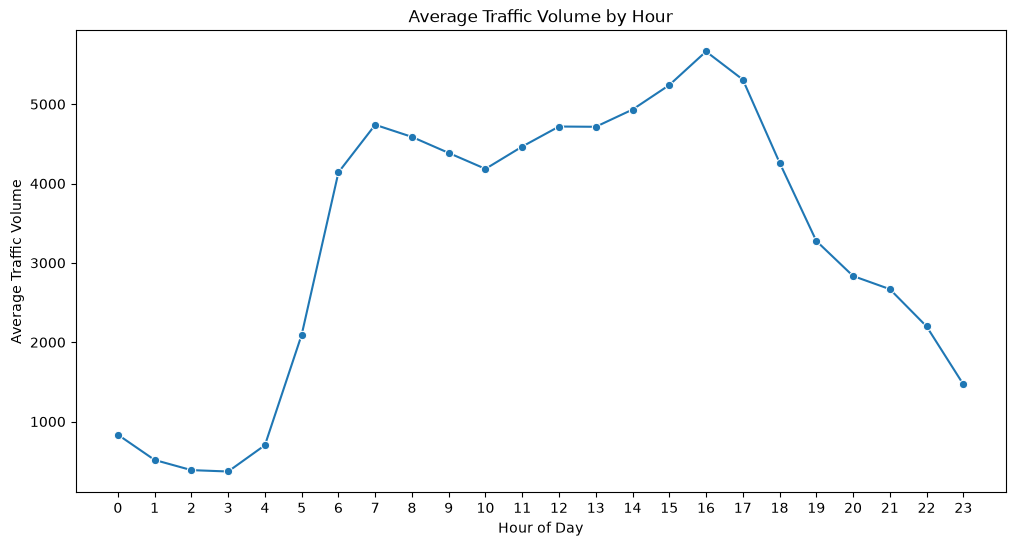

In [24]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_traffic,
    x="hour",
    y="traffic_volume",
    marker="o"
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")

plt.xticks(range(24))

plt.show()

In [25]:
peak_hour = hourly_traffic.loc[
    hourly_traffic["traffic_volume"].idxmax()
]

peak_hour

hour                16.000000
traffic_volume    5663.756539
Name: 16, dtype: float64

In [26]:
peak_hour["hour"]

np.float64(16.0)

In [27]:
peak_hour["traffic_volume"]

np.float64(5663.756539235413)

In [28]:
lowest_hour = hourly_traffic.loc[
    hourly_traffic["traffic_volume"].idxmin()
]

lowest_hour

hour                3.000000
traffic_volume    371.090864
Name: 3, dtype: float64

In [31]:
daily_traffic = (
    df.groupby("day_name")["traffic_volume"]
    .mean()
    .reset_index()
)
daily_traffic

,day_name,traffic_volume
0,Friday,3656.358836
1,Monday,3309.387161
2,Saturday,2773.638120
3,Sunday,2368.588329
4,Thursday,3637.899663
5,Tuesday,3488.555799
6,Wednesday,3583.196681


In [32]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [33]:
daily_traffic["day_name"] = pd.Categorical(
    daily_traffic["day_name"],
    categories=day_order,
    ordered=True
)

daily_traffic = daily_traffic.sort_values("day_name")

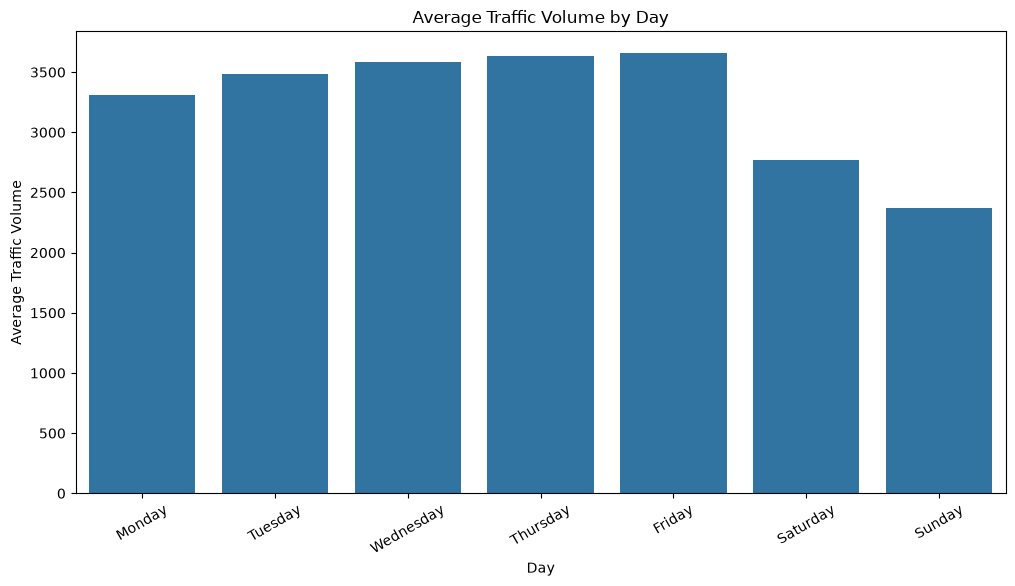

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=daily_traffic,
    x="day_name",
    y="traffic_volume"
)

plt.title("Average Traffic Volume by Day")
plt.xlabel("Day")
plt.ylabel("Average Traffic Volume")

plt.xticks(rotation=30)

plt.show()

In [35]:
monthly_traffic = (
    df.groupby("month")["traffic_volume"]
    .mean()
    .reset_index()
)

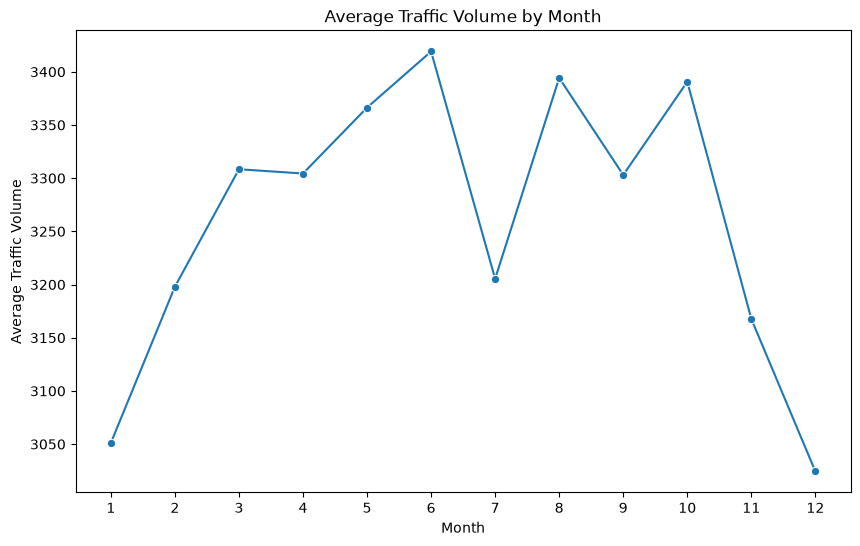

In [36]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_traffic,
    x="month",
    y="traffic_volume",
    marker="o"
)

plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")

plt.xticks(range(1, 13))

plt.show()

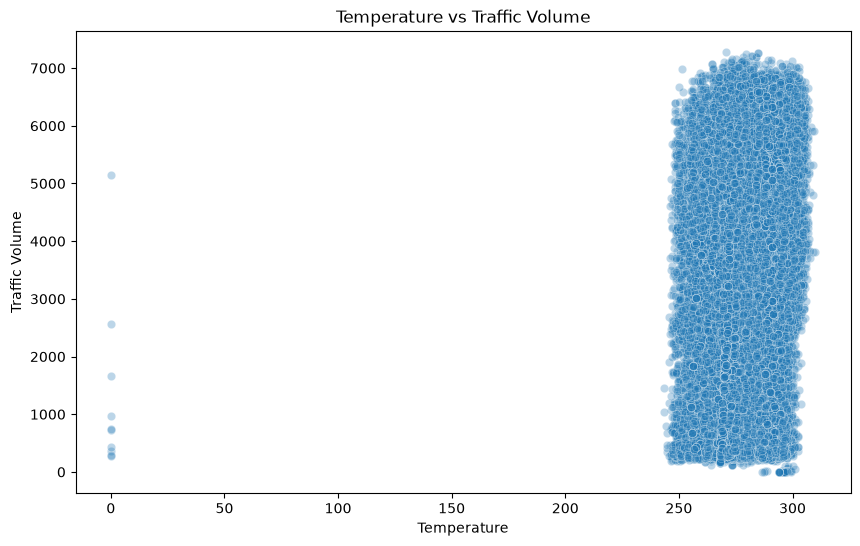

In [37]:
# Traffic vs Temperature
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temp",
    y="traffic_volume",
    alpha=0.3
)

plt.title("Temperature vs Traffic Volume")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")

plt.show()

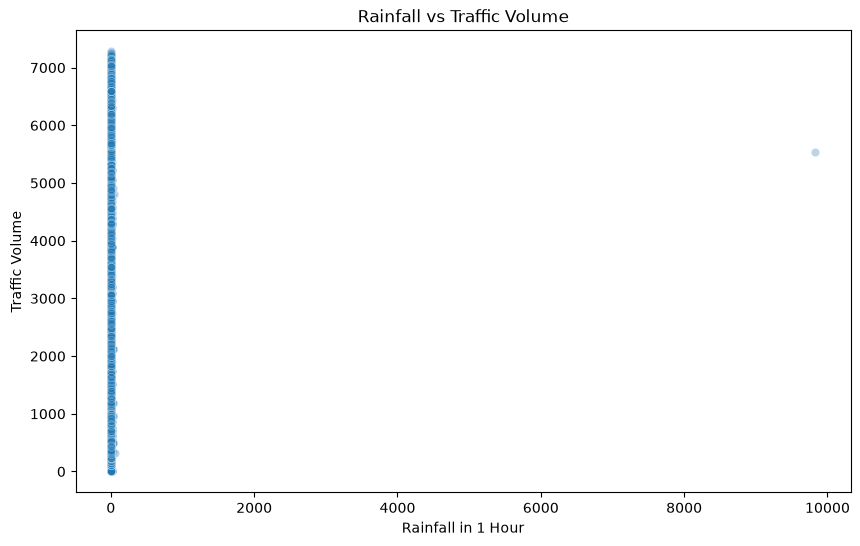

In [38]:
# Traffic vs Rain
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="rain_1h",
    y="traffic_volume",
    alpha=0.3
)

plt.title("Rainfall vs Traffic Volume")
plt.xlabel("Rainfall in 1 Hour")
plt.ylabel("Traffic Volume")

plt.show()

In [39]:
# Traffic by Weather Condition
df["weather_main"].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [40]:
weather_traffic = (
    df.groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

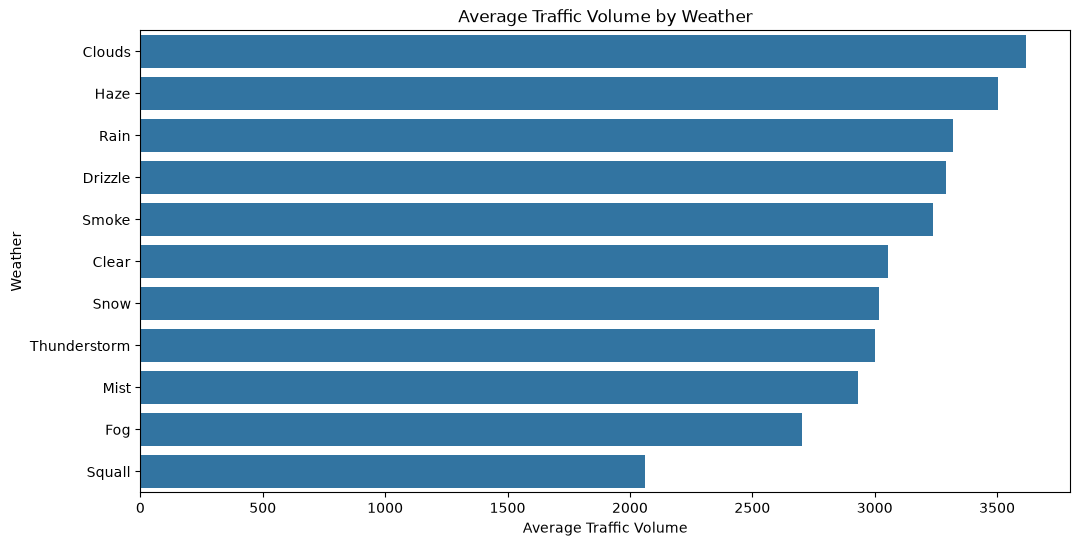

In [41]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=weather_traffic,
    x="traffic_volume",
    y="weather_main"
)

plt.title("Average Traffic Volume by Weather")
plt.xlabel("Average Traffic Volume")
plt.ylabel("Weather")

plt.show()

In [42]:
# Rush Hour Analysis
rush_hours = [7, 8, 9, 16, 17, 18, 19]

In [43]:
df["is_rush_hour"] = df["hour"].isin(rush_hours)

In [44]:
rush_traffic = (
    df.groupby("is_rush_hour")["traffic_volume"]
    .mean()
)

rush_traffic

is_rush_hour
False    2707.142598
True     4603.987184
Name: traffic_volume, dtype: float64

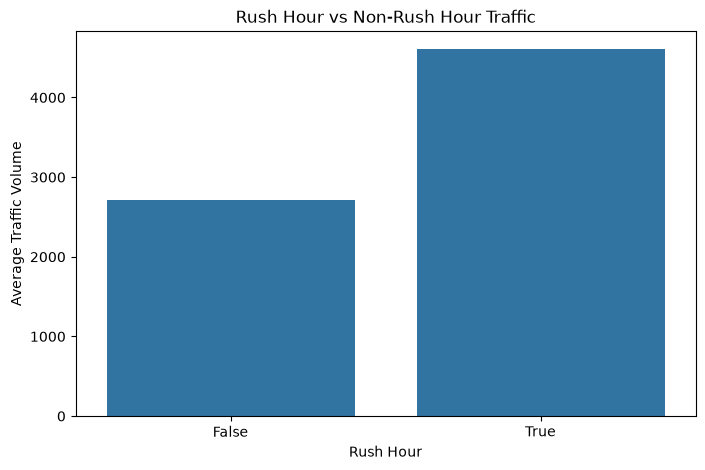

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=rush_traffic.index.astype(str),
    y=rush_traffic.values
)

plt.title("Rush Hour vs Non-Rush Hour Traffic")
plt.xlabel("Rush Hour")
plt.ylabel("Average Traffic Volume")

plt.show()

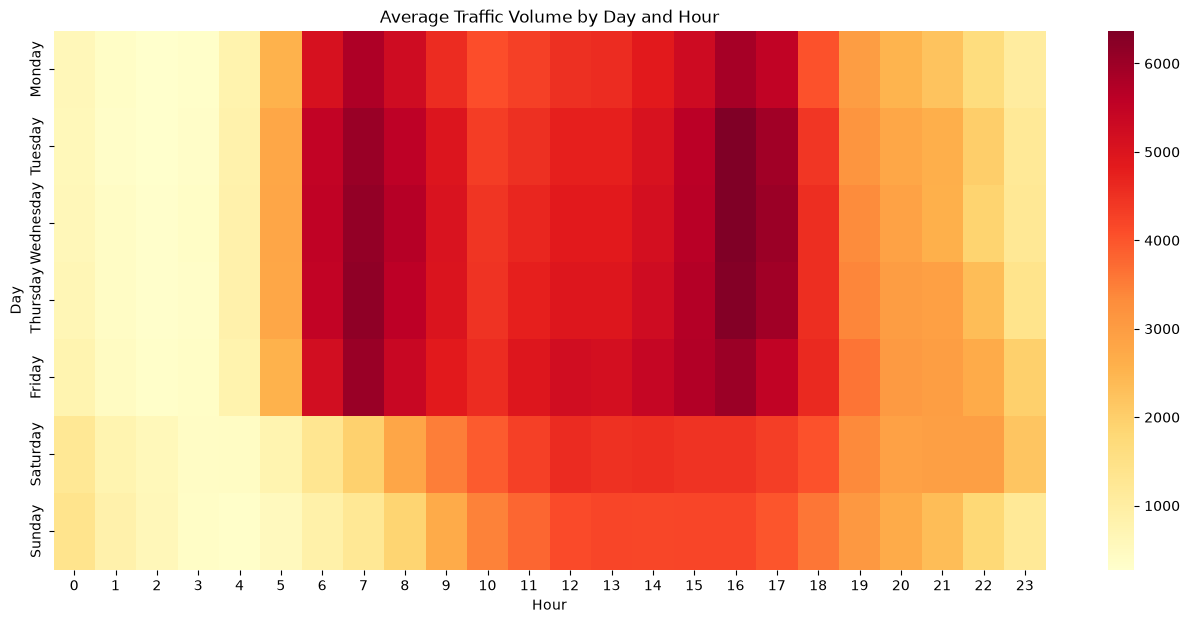

In [47]:
# Traffic Heatmap — Hour vs Day
heatmap_data = df.pivot_table(
    index="day_name",
    columns="hour",
    values="traffic_volume",
    aggfunc="mean"
)
heatmap_data = heatmap_data.reindex(day_order)
# plot
plt.figure(figsize=(16, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title("Average Traffic Volume by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

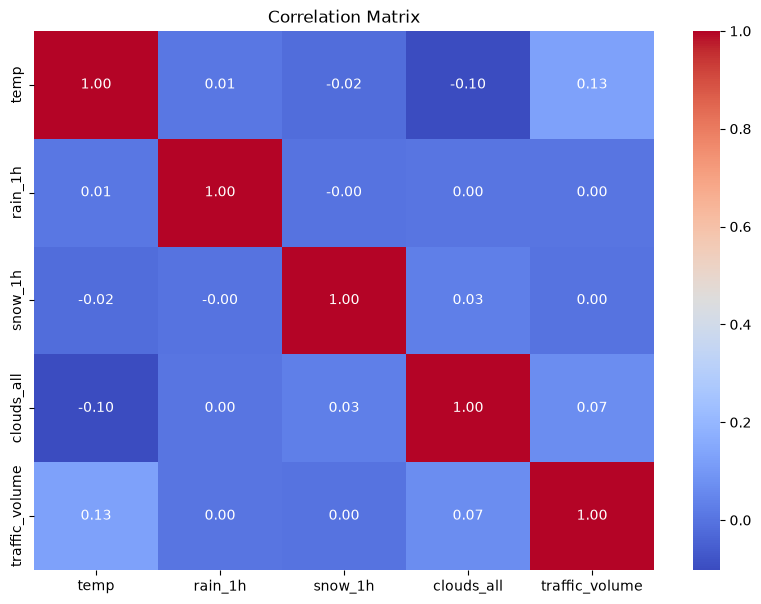

In [48]:
# Correlation Analysis
numeric_columns = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "traffic_volume"
]

correlation = df[numeric_columns].corr()

correlation

# plot
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

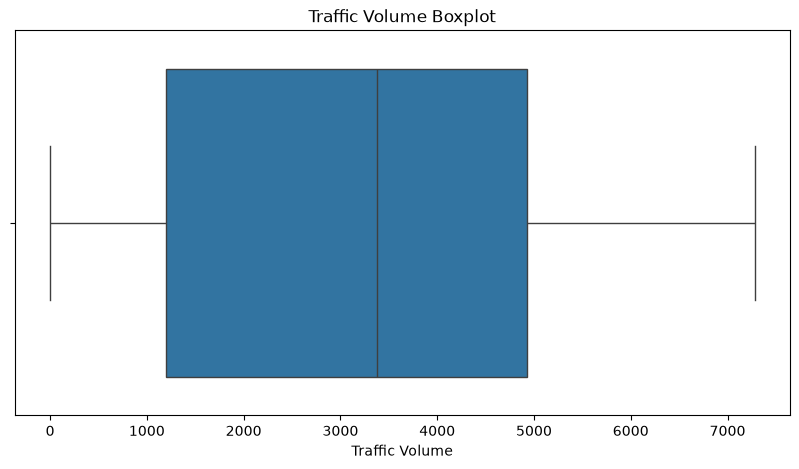

In [49]:
# Find Traffic Outliers
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["traffic_volume"]
)

plt.title("Traffic Volume Boxplot")
plt.xlabel("Traffic Volume")

plt.show()

In [50]:
Q1 = df["traffic_volume"].quantile(0.25)
Q3 = df["traffic_volume"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [51]:
outliers = df[
    (df["traffic_volume"] < lower_bound)
    | (df["traffic_volume"] > upper_bound)
]

len(outliers)

0

<!--                             an EDA Summary                                                   -->
Here is a summary of the data quality checks and key traffic insights found in the file:📊 Dataset OverviewSize: The dataset contains 48,204 rows and 9 columns.Target: The main thing to predict is traffic_volume.Other Information: It tracks weather details, temperatures, and dates.🛠️ Data Quality & CleaningMissing Data: The holiday column is missing 99.87% of its data because most days are regular days, not holidays. All other columns are complete.Duplicates: There are 17 hidden duplicate rows that need to be removed.Fixes: The date_time text column was successfully changed into a real computer date field to extract time features.Data Errors:The weather tracker shows a huge error where rain_1h spikes to a maximum of 9,831.3 mm.The temperature tracker drops to 0.0 Kelvin (absolute zero), which is a data error.🕒 Key Traffic InsightsHourly Waves: Traffic forms multiple hills throughout the day.Busiest Time: The ultimate peak traffic hour is 4:00 PM (16:00) with an average of 5,663 cars.Quietest Time: The road is loneliest at 3:00 AM with an average of only 371 cars.Rush Hour vs. Normal: Rush hours average 4,604 cars, while normal hours average 2,707 cars.Weekly Trends: Weekdays (Monday through Friday) are very busy, but traffic drops heavily on weekends, especially on Sundays.⛅ Weather ImpactsCommon Weather: Cloudy and clear days are recorded the most in this data.Outliers: There are zero statistical outliers when looking at the traffic volume column alone using standard boxplot rules.🧪 Features Created for Machine LearningNew columns were made to isolate the exact year, month, day, hour, day of the week, and day name to help the machine learning model learn faster.Now that your data is cleaned and explored, would you like me to help you:Write a script to remove the 17 duplicate rows and filter out the bad weather data (like 0.0 Kelvin)?Set up a Train-Test split to start training your first prediction model?